# Vision-Language Models (VLM): Часть 1

***

## Содержание

1. [Введение: чисто текстовые модели](#введение-чисто-текстовые-модели)
   - Encoder-decoder
   - Decoder-only модели
2. [История VLM](#история-vlm)
   - CLIP и SigLIP (напоминание)
   - GLIP
   - BLIP-2 и VQA
   - Состояние LLM перед LLaVA / LLaVA
   - PaLI
   - Позиционные эмбеддинги: RoPE, RoPE-2D, mRoPE, YaRN
3. [Современные архитектуры](#современные-архитектуры)
   - [InternVL](#internvl)
   - [Gemma 2/3/4](#gemma-234)
   - [Qwen-VL](#qwen-vl)
   - [Семейство GLM](#семейство-glm)
4. [Open-source vs Closed-source](#open-source-vs-closed-source)
5. [Как обучаются современные VLM: итоговое саммари](#как-обучаются-современные-vlm-итоговое-саммари)

***

# Введение: чисто текстовые модели

## Encoder-Decoder архитектура

Модели типа **encoder-decoder** (seq2seq) — исторически первый класс Transformer-архитектур, применявшийся к задачам, где входная и выходная последовательности могут иметь разную длину и семантику.

Этот класс моделей сформировался в контексте задачи **машинного перевода**. До Transformer-эпохи (до 2017) нейросетевой машинный перевод строился на RNN-энкодерах-декодерах (Sutskever et al., 2014; Bahdanau et al., 2015) с механизмом внимания. Transformer (Vaswani et al., 2017) принципиально ускорил и улучшил эту схему, но сохранил ту же двухкомпонентную идею. Первые большие Transformer-модели — **T5** (Raffel et al., 2019) и **BART** (Lewis et al., 2019) — были именно encoder-decoder и доминировали на задачах NLP (перевод, суммаризация, QA) вплоть до 2020–2021 годов.

**Переход к decoder-only** произошёл с выходом GPT-3 (Brown et al., 2020), который показал, что единый декодер с авторегрессивным пре-трейном способен решать те же задачи через in-context learning — без отдельного энкодера. Затем InstructGPT и ChatGPT продемонстрировали, что decoder-only модели масштабируются лучше и гибче. Сегодня T5-подобные энкодер-декодеры встречаются в специализированных продуктах (Google Translate, FLAN-T5), но в качестве основы для VLM decoder-only безоговорочно доминирует — за исключением PaLI (см. ниже).

**Схема работы:**

```
Вход: x_1, x_2, ..., x_S   →   [Encoder] → z_1, z_2, ..., z_S
                                               ↓
                              [Decoder + Cross-Attention] → y_1, y_2, ..., y_T
```

**Encoder** кодирует входную последовательность в скрытые состояния $$\mathbf{z} = (\mathbf{z}_1, \ldots, \mathbf{z}_S)$$ посредством стека слоёв с двунаправленным self-attention:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

В encoder каждый токен может «смотреть» на все остальные — нет причинной маски. Это обеспечивает полный контекст, что полезно для задач понимания.

**Decoder** генерирует выходную последовательность авторегрессионно. Каждый его слой содержит:
1. **Masked self-attention** — декодер видит только уже сгенерированные токены (причинная маска, causal mask).
2. **Cross-attention** — запросы берутся из декодера, а ключи и значения — из энкодерных представлений $\mathbf{z}$:

$$
\text{CrossAttention}(Q_{\text{dec}}, K_{\text{enc}}, V_{\text{enc}}) = \text{softmax}\!\left(\frac{Q_{\text{dec}} K_{\text{enc}}^\top}{\sqrt{d_k}}\right) V_{\text{enc}}
$$

3. **FFN**.

**Обучение** ведётся с помощью teacher forcing: на вход декодера подаётся правильная целевая последовательность (со сдвигом на 1), а лосс — cross-entropy по каждой позиции.

**Ключевые примеры:** T5, mT5, BART, mBART. В VLM-контексте — PaLI (см. ниже).

***

## Decoder-Only модели

Decoder-only — ныне доминирующая парадигма для языковых и мультимодальных моделей.

### Архитектура

Один стек трансформерных слоёв, где каждый слой имеет только **causal self-attention** (причинная маска) и **FFN**. Нет отдельного энкодера, нет cross-attention. Входная последовательность и контекст — единая конкатенация.

Принципиальный отличительный момент: **autoregressive next-token prediction** — единственная тренировочная задача:

$$
\mathcal{L} = -\sum_{t=1}^{T} \log p_\theta(x_t \mid x_1, \ldots, x_{t-1})
$$

Это делает архитектуру универсальной: задача, описание, пример — всё это просто токены, которые идут перед ответом.

### Causal mask

При вычислении attention применяется нижнетреугольная маска:

$$
M_{ij} = \begin{cases} 0 & j \leq i \\ -\infty & j > i \end{cases}
$$

После применения softmax позиция $i$ получает ненулевые веса только от позиций $\leq i$.

### Работа с последовательностями разной длины

Здесь важны два аспекта:

**1. Батч-обработка (padding / packing)**

При обучении на батчах последовательности разной длины либо **дополняются** (padding) до максимальной длины в батче с маскированием паддинговых позиций, либо **упаковываются** (packing / sequence packing): несколько коротких последовательностей объединяются в одну длинную с разделяющими токенами. Packing более эффективен вычислительно: GPU всегда загружен «реальными» токенами, а не паддингом.

**2. KV-cache при инференсе**

При авторегрессивной генерации на каждом шаге $t$ вычислять внимание ко всем предыдущим токенам «с нуля» накладно. Вместо этого кешируются $K$ и $V$ для всех предыдущих позиций. Шаг $t$ требует только вычисления нового $q_t$ и dot-product с кешированными ключами:

$$
\text{cost per step} = O(t \cdot d_k) \quad \text{вместо} \quad O(t^2 \cdot d_k)
$$

Это снижает сложность с $O(T^2)$ до $O(T)$ по числу шагов, хотя требует $O(T \cdot d_k \cdot L)$ памяти (где $L$ — число слоёв). При длинных контекстах KV-cache становится узким местом по памяти.

**Интересный факт:** decoder-only архитектуры впервые показали конкурентоспособность с encoder-decoder на задачах машинного перевода в исследованиях GPT-3, несмотря на то, что традиционно считалось, что для таких задач нужен двунаправленный энкодер.

***


# История VLM

## CLIP и SigLIP: напоминание

> **CLIP:** Radford et al., "Learning Transferable Visual Models From Natural Language Supervision", ICML 2021. https://arxiv.org/abs/2103.00020  
> **SigLIP:** Zhai et al., "Sigmoid Loss for Language Image Pre-Training", ICCV 2023. https://arxiv.org/abs/2303.15343

> *(Подробный разбор был в предыдущих лекциях — здесь только структурное напоминание.)*

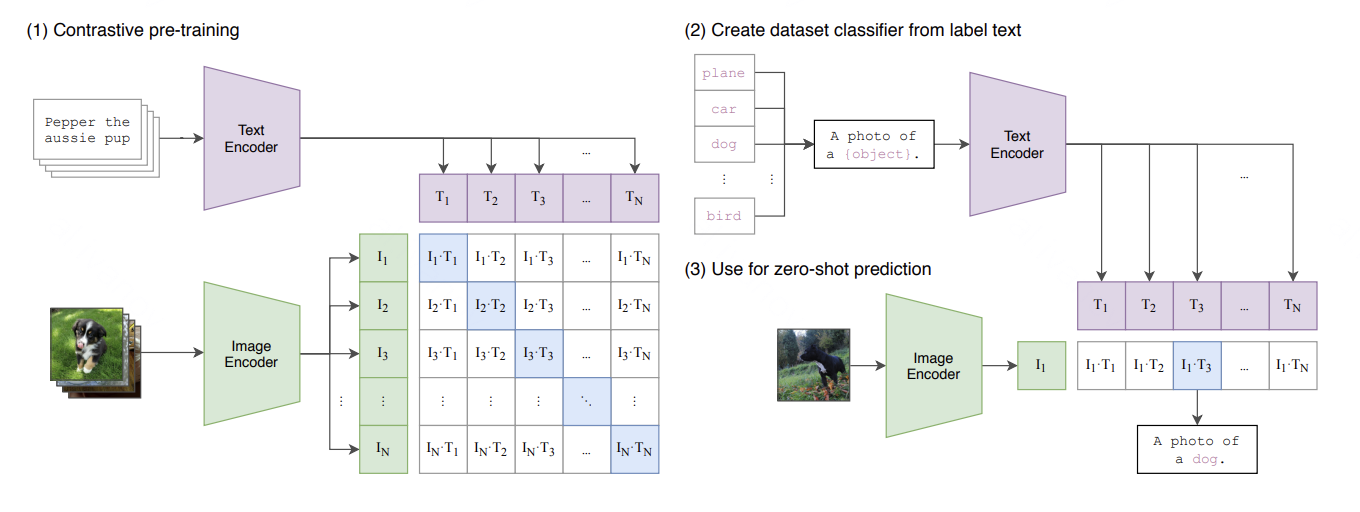

рисунок архитектуры CLIP из оригинальной статьи (Radford et al., 2021, Figure 1) — два энкодера (image + text), совместное обучение на (image, text) парах, матрица косинусных сходств

**CLIP (OpenAI, 2021):** два независимых энкодера — image encoder (ViT или ResNet) и text encoder (Transformer) — проецируют свои модальности в единое $d$-мерное нормализованное пространство. Обучение — InfoNCE контрастивный лосс на 400M пар (image, text). Главный результат: zero-shot inference — изображение классифицируется через косинусное сходство с текстовыми описаниями классов без дообучения. CLIP ViT-L/14 стал стандартным visual encoder для первого поколения VLM (LLaVA, InstructBLIP).

**SigLIP (Google, 2023):** заменяет softmax-нормализацию по батчу на попарный sigmoid loss. Ключевое преимущество — не требует глобальной нормировки, масштабируется до batch size 1M, устойчив к малым батчам. SigLIP-SO400M стал стандартным visual encoder в Gemma 3/4 и ряде других современных VLM.

***

## GLIP: Grounded Language–Image Pre-Training

> **Статья:** Li et al., "Grounded Language-Image Pre-training", CVPR 2022.  
> **Ссылка:** https://arxiv.org/abs/2112.03857

GLIP (Microsoft Research, 2021) расширяет идею CLIP до задачи **object detection через phrase grounding**.

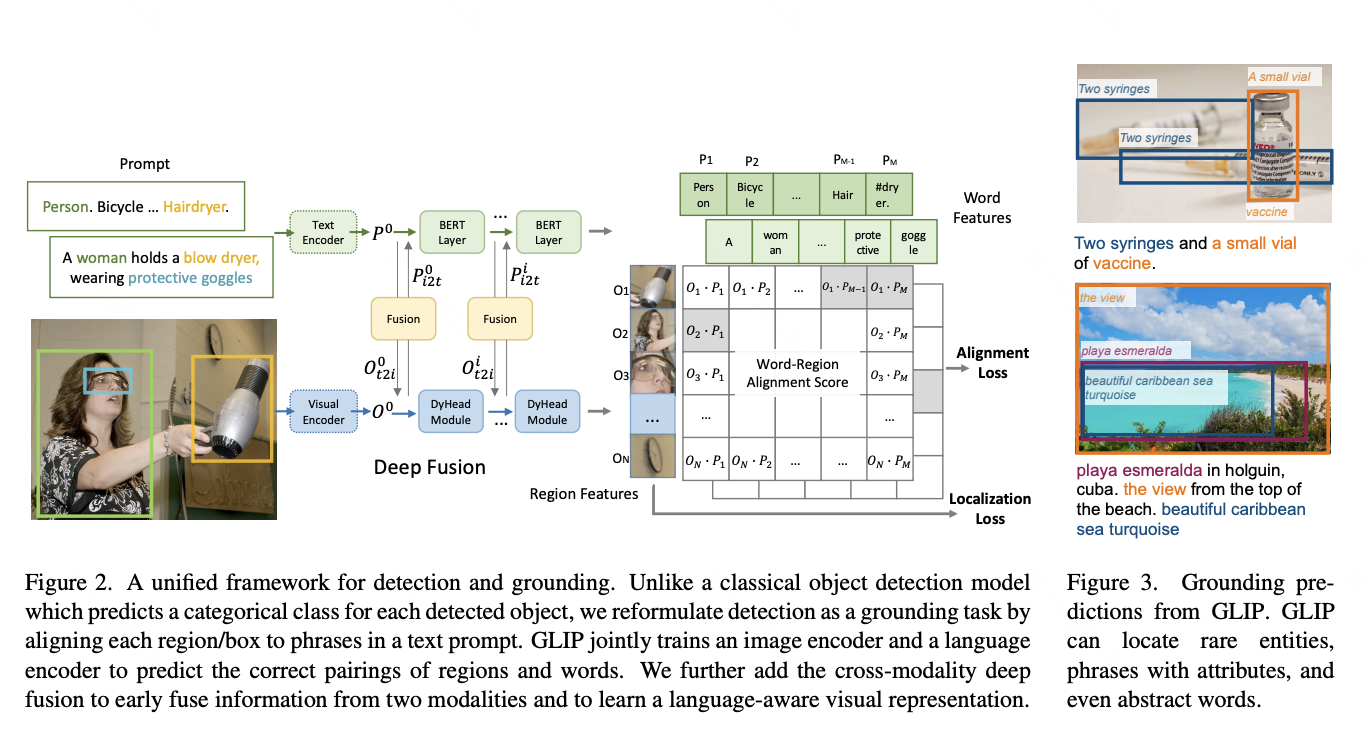
схема GLIP из оригинальной статьи (Li et al., 2021) — image encoder + text encoder с deep cross-modal fusion, предсказание bounding boxes через alignment region-phrase

### Ключевая идея: унификация detection и grounding

Классический детектор предсказывает категориальные метки («кошка», «собака»). GLIP **реформулирует детекцию как grounding**: каждый bounding box должен быть выровнен с фразой из текстового запроса.

Это позволяет:
1. Обучаться на любых текстах с bounding boxes (а не только на фиксированном наборе классов)
2. Применять zero-shot детекцию к новым классам через текстовое описание

**Cross-modal deep fusion:** в отличие от CLIP, где два энкодера независимы до финального проецирования, GLIP вводит cross-attention между image и text representations в промежуточных слоях. Это позволяет языковым признакам влиять на визуальные ещё в процессе энкодинга — так называемый «глубокий fusion», в противоположность «поверхностному alignment» (shallow alignment), где модальности объединяются только в конце.

Функция потерь:

$$
\mathcal{L}_{\text{GLIP}} = \mathcal{L}_{\text{loc}} + \mathcal{L}_{\text{align}}
$$

где $\mathcal{L}_{\text{loc}}$ — стандартный regression + classification loss для bounding boxes, а $\mathcal{L}_{\text{align}}$ — contrastive loss для совмещения регионных эмбеддингов с фразовыми.

**Данные:** 3M размеченных + 24M веб-скреопленных пар (image, text), итого 27M. Боксы для веб-данных генерируются в self-training режиме.

**Достижение:** zero-shot COCO: 49.8 AP, после fine-tuning: 60.8 AP.

***

## BLIP-2: Q-Former как универсальный мост между ViT и LLM

> **Статья:** Li et al., "BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Unimodal Models", ICML 2023.  
> **Ссылка:** https://arxiv.org/abs/2301.12597

BLIP-2 (Salesforce, 2023) — ключевая работа, заложившая одну из двух главных парадигм соединения ViT с LLM. В отличие от последующей LLaVA, BLIP-2 предлагает специализированный **Q-Former** модуль, а не простую линейную проекцию.

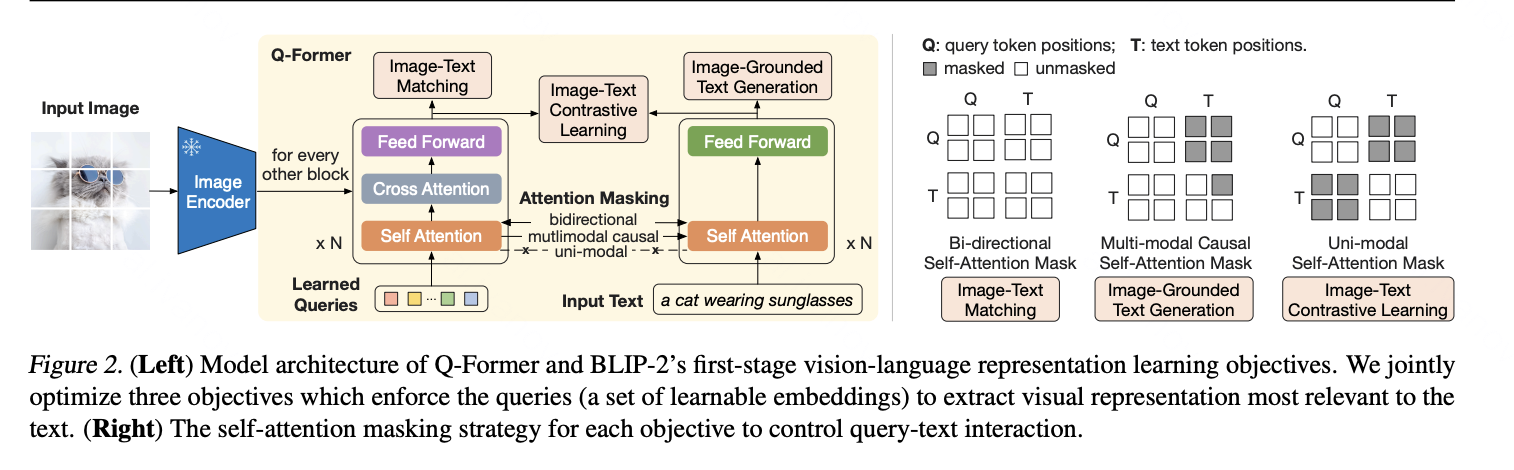

схема BLIP-2 из оригинальной статьи (Li et al., 2023) — Frozen Image Encoder → Q-Former → Frozen LLM, Q-Former состоит из Image Transformer + Text Transformer с shared self-attention

### Мотивация: проблема мостика между модальностями

К 2023 году существовали две группы высококачественных претренированных моделей: мощные image encoders (CLIP ViT-L, EVA ViT-G) и мощные LLM (OPT, FLAN-T5). Проблема — прямое соединение их нецелесообразно: размерности не совпадают, semantic space разный, совместное дообучение разрушает накопленные знания (catastrophic forgetting). BLIP-2 решает задачу: **как подключить замороженный ViT к замороженному LLM, не разрушив ни тот, ни другой?**

Ответ — Q-Former: лёгкий модуль, который обучается «между» двумя замороженными гигантами.

### Архитектура Q-Former

Q-Former — 12-слойный трансформер (инициализируется из весов BERT) с двумя «потоками» внутри:

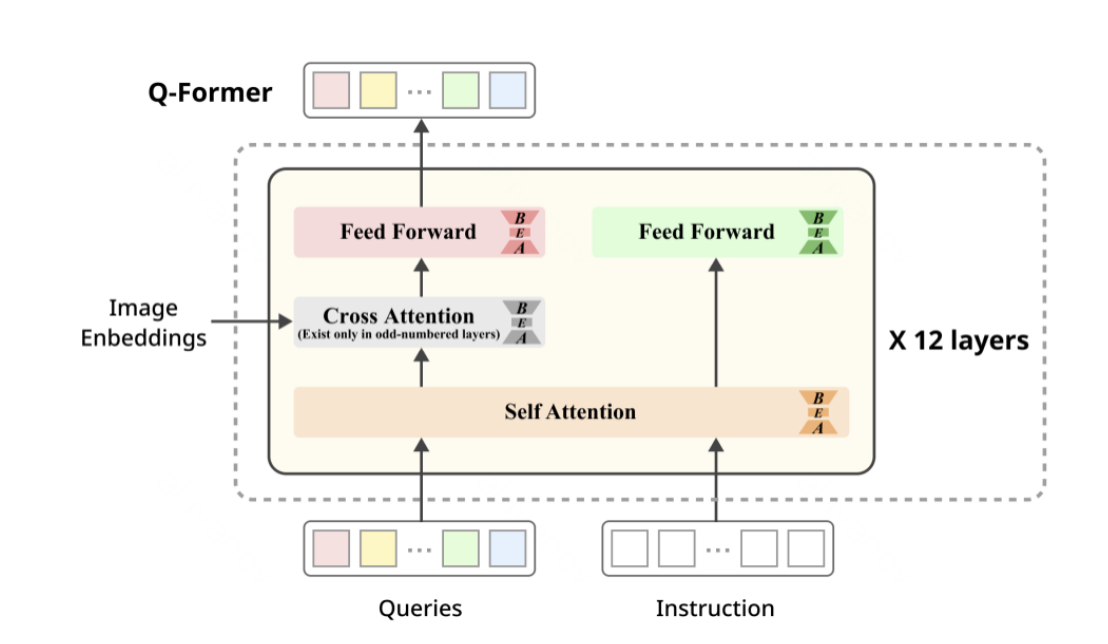

**Ключевые элементы:**
- **Learnable query vectors** $Q \in \mathbb{R}^{N_q \times d}$, $N_q = 32$: обучаемые параметры (не входные данные!). Они извлекают «нужную» информацию из ViT через cross-attention.
- **Shared self-attention:** query-векторы и текстовые токены делят одни self-attention слои. Это позволяет запросам учитывать текстовый контекст при извлечении визуальных признаков.
- **Cross-attention** — соединяет query-векторы с ViT-выходом. ViT заморожен — только K, V.

**Параметры Q-Former:** ~188M (только Q-Former), при том что ViT-G (~1.8B) и OPT-6.7B (~6.7B) заморожены.

### Двухстадийное предобучение

**Стадия 1 — Vision-Language Representation Learning** (с замороженным ViT):

Q-Former обучается с тремя задачами одновременно через разные маски self-attention:

| Задача | Маска self-attention | Цель |
|--------|---------------------|------|
| **ITC** (Image-Text Contrastive) | Unimodal — query и text независимы | Выравнивание глобальных эмбеддингов |
| **ITM** (Image-Text Matching) | Bidirectional — query ↔ text | Бинарная классификация совпадения пары |
| **ITG** (Image-Grounded Text Generation) | Causal on text, queries видны тексту | Генерация caption по изображению |

Все три задачи обучают **одни и те же** веса Q-Former — просто с разными масками attention. Это обеспечивает многостороннее понимание relationship между изображением и текстом.

Математически для ITG: запросы видят ViT через cross-attention, текстовые токены видят запросы, но не будущие токены (causal mask). Лосс:

$$
\mathcal{L}_{\text{ITG}} = -\sum_{t} \log p_\theta(\text{token}_t \mid \text{query tokens}, \text{token}_{<t})
$$

**Стадия 2 — Vision-to-Language Generative Learning** (с замороженным LLM):

Выходы Q-Former (32 visual tokens) проецируются через FC-слой в embedding space LLM и **конкатенируются** с текстовыми токенами как «мягкие визуальные подсказки»:

$$
\text{LLM input} = [\underbrace{W_p \cdot Z_Q}_{\text{32 visual tokens}}, \underbrace{\text{text tokens}}_{\text{вопрос/инструкция}}]
$$

где $W_p$ — проекционный FC-слой, $Z_Q$ — выход Q-Former.

При использовании **decoder-based LLM** (OPT): LM loss на генерацию текстового ответа. При **encoder-decoder LLM** (FlanT5): visual tokens идут на вход encoder, ответ генерирует decoder.

### Visual Question Answering (VQA)

VQA — задача ответа на вопрос по изображению — стала главным демонстрационным benchmark для BLIP-2.

**Формат входа при VQA:**

```
[Visual tokens (32)] [Question: "What color is the car?"] → Answer: "red"
```

При zero-shot VQA (без fine-tuning на VQA датасете): BLIP-2 FlanT5-XXL достигает **65.0** на VQAv2 — значительно лучше предыдущих SOTA zero-shot методов (Flamingo-80B: 56.3).

При fine-tuning: модель дообучается на VQAv2 train split, при этом ViT и LLM остаются замороженными — обновляется только Q-Former + FC-слой (+ опционально часть LLM через LoRA).

**Форматы VQA-ответов:**
- **Closed-form (VQAv2):** ответы из заданного словаря, метрика — accuracy
- **Open-ended:** свободная генерация, метрика — CIDEr/BLEU или GPT-судья

**Интересный момент:** BLIP-2 без VQA-дообучения превосходит модели с дообучением, если они на порядки меньше. Это говорит о том, что Q-Former эффективно передаёт визуальные признаки в семантическое пространство LLM.

### Ограничения BLIP-2 и эволюция к LLaVA

**Проблемы Q-Former:**
- **Фиксированный bottleneck:** 32 query-токена не масштабируются с разрешением — при высоком разрешении детали теряются
- **Сложность обучения:** три задачи одновременно, медленная сходимость
- **Слабое instruction following:** LLM заморожен → плохо следует сложным инструкциям

LLaVA (см. следующий раздел) показала, что при правильно составленных instruction-following данных простая линейная проекция + SFT LLM работает лучше.

***


## Состояние LLM к моменту появления LLaVA (2022–2023)

Прежде чем перейти к LLaVA, полезно восстановить контекст: что происходило в NLP к моменту её появления.

**GPT-3 (2020, OpenAI):** 175B-параметровая decoder-only модель, обученная на 300B токенах. Показала, что масштаб позволяет решать новые задачи через few-shot prompting без дообучения. Закрыта, доступна только через API. Создала огромный интерес к крупным LLM, но не сделала их доступными для исследователей.

**Chinchilla (2022, DeepMind):** Hoffmann et al. перевернула представления об оптимальном соотношении данных и параметров. Chinchilla-70B превзошёл GPT-3 (175B) и Gopher (280B), обучившись на 1.4T токенов вместо 300B. Вывод: большинство LLM того времени были **недообучены** — компании масштабировали параметры, не масштабируя данные. Формула: оптимальное число токенов ≈ 20× числа параметров.

**PaLM (2022, Google):** 540B-параметровая модель с впечатляющим качеством на chain-of-thought reasoning. Закрыта. Продемонстрировала «возникающие способности» (emergent abilities) — внезапное качественное улучшение при достижении определённого масштаба.

**InstructGPT / ChatGPT (2022–2023, OpenAI):** применение RLHF поверх GPT-3 base. Это сделало модели «послушными» и удобными для диалога. ChatGPT (ноябрь 2022) стал вирусным феноменом — 100M пользователей за 2 месяца. Показал, что alignment через RLHF критичен для практического применения.

**Открытые альтернативы в 2022 — начале 2023:** OPT (Meta, 2022, до 175B, открыта), BLOOM (BigScience, 2022, 176B, открыта), GPT-NeoX (EleutherAI, 2022, 20B). Все они уступали GPT-3 по качеству. Открытость без производительности — не то, что нужно исследователям.

**LLaMA (февраль 2023, Meta):** в этот момент Meta выпускает LLaMA — коллекцию моделей от 7B до 65B, обученных на **1T+ токенах** публично доступных данных. Ключевой результат: **LLaMA-13B превосходит GPT-3 (175B) на большинстве бенчмарков**, несмотря на то, что в 13× меньше. LLaMA-65B конкурирует с Chinchilla-70B и PaLM-540B. Meta выпустила LLaMA для исследователей (по запросу), но веса утекли в интернет. Это спровоцировало взрыв open-source активности.

**Vicuna (март 2023):** LLaMA-13B, дообученная на 70K диалогов из ShareGPT (публично опубликованные ChatGPT-разговоры). GPT-4 оценивал Vicuna-13B как достигающую 92% качества ChatGPT. Именно Vicuna стала языковой базой первой версии LLaVA.

**Контекст создания LLaVA:** к весне 2023 у исследователей впервые появился открытый, качественный decoder-only LLM (Vicuna), достаточно мощный, чтобы на его базе строить мультимодальные системы. BLIP-2 уже показал, что Q-Former может связать ViT с LLM. Вопрос был: нужна ли архитектурная сложность Q-Former, или хватит более простого соединения?

***

### LAMA != LLAMA
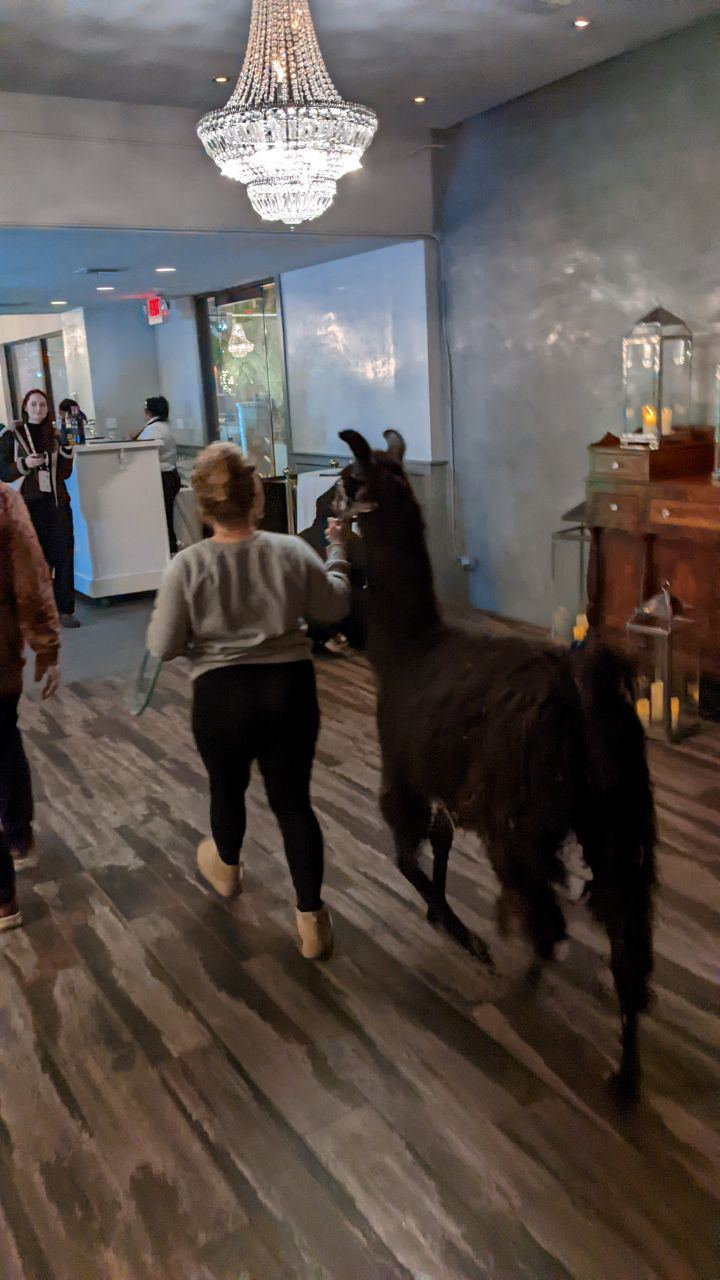


## LLaVA: подключение ViT к LLM через простую проекцию

> **Статья:** Liu et al., "Visual Instruction Tuning", NeurIPS 2023.  
> **Ссылка:** https://arxiv.org/abs/2304.08485

LLaVA (Haotian Liu et al.) — первый шаблон, ставший индустриальным стандартом для VLM.


### Контекст: LLaVA vs BLIP-2

BLIP-2 (разобран в предыдущем разделе) показал принцип: Q-Former как мост между замороженным ViT и LLM. LLaVA предложила альтернативный, более радикальный ответ: никакого специального «моста» — только линейная проекция. Но при качественных instruction-following данных и SFT самого LLM простота выигрывает у сложности.

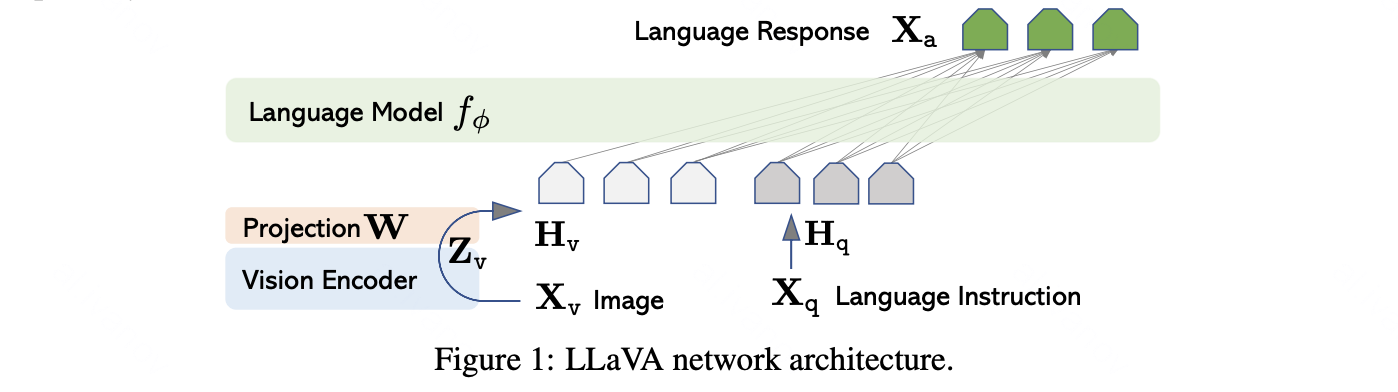

схема LLaVA из оригинальной статьи (Liu et al., 2023, Figure 1) — CLIP ViT-L/14 → linear projection → LLM (Vicuna), входная последовательность = [img tokens] + [text tokens]


Проекция — **просто линейный слой**. Никакого Q-Former-а, никаких cross-attention слоёв между модальностями. Простота оказалась достоинством.

**CLIP ViT-L/14** при разрешении 224×224 порождает $N_v = (224/14)^2 = 256$ патч-токенов (без CLS-токена). Каждый имеет размерность $d_v = 1024$. Проекция переводит их в $d_{\text{llm}} = 5120$ (для Vicuna-13B), и все 256 токенов подаются на вход LLM.

### Двухстадийное обучение

**Stage 1 — Feature alignment (pre-training):**

Обучается **только проекционная матрица** $W$. LLM и ViT заморожены.

Данные: подмножество CC3M (~595K image-text пар). Задача: предсказать caption по изображению. Это «обучает» $W$ быть мостом между пространствами признаков ViT и embedding space LLM.

**Stage 2 — End-to-end fine-tuning:**

Обучается $W$ **и** LLM (ViT по-прежнему заморожен). Используется мультимодальный instruction-following датасет, сгенерированный GPT-4: диалоги на основе изображений — 158K примеров.

Ключевой insight: GPT-4 может генерировать мультимодальные диалоги высокого качества, имея только текстовое описание изображения (caption + bounding boxes). Это позволяет масштабировать данные дёшево.

LLaVA достигает **85.1% relative score** к GPT-4 на синтетическом бенчмарке, используя модель в 7B параметров.

### Ключевые наблюдения

- Visual tokens конкатенируются с text tokens и обрабатываются **единым** авторегрессивным трансформером — никакой специальной архитектуры слияния не нужно
- LLM «понимает» изображения потому, что его embedding space через $W$ получает смысловые признаки из CLIP-пространства
- Замораживание ViT на обоих этапах предотвращает catastrophic forgetting

***


## PaLI: альтернативный подход — Encoder-Decoder VLM

> **Статья:** Chen et al., "PaLI: A Jointly-Scaled Multilingual Language-Image Model", ICLR 2023.  
> **Ссылка:** https://arxiv.org/abs/2209.06794

PaLI (Google, 2022) показал, что для VLM можно использовать encoder-decoder LM вместо decoder-only.

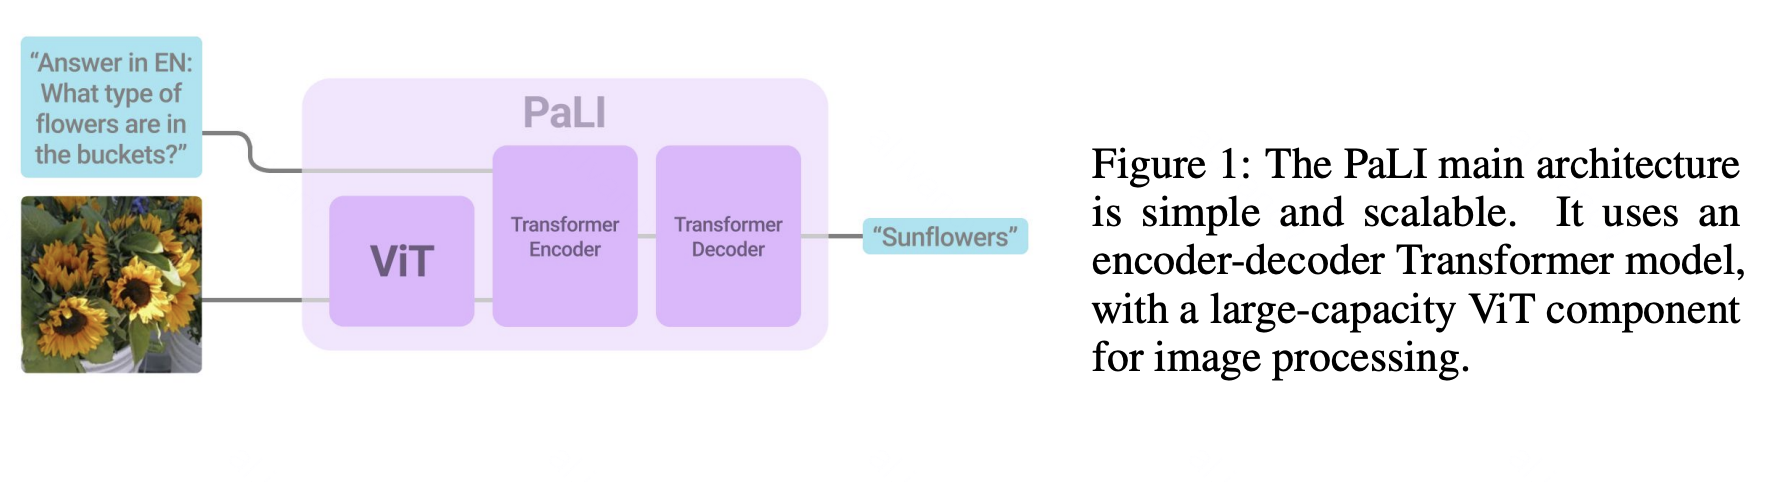
схема PaLI из оригинальной статьи — ViT → токены изображения в encoder mT5 → decoder генерирует текст

### Архитектура

Принципиальное отличие от LLaVA: **image tokens подаются на вход encoder-а**, а не decoder-а. Decoder затем генерирует текст через cross-attention к encoder outputs.

Языковая часть — **mT5-XXL (13B параметров)**. Визуальная часть — специально обученный **ViT-e (enormous, 4B параметров)** — крупнейший ViT на момент публикации.

**Главный тезис PaLI:** визуальные и языковые компоненты нужно масштабировать совместно. Пока language models были 10B+, а ViT — 300M, визуальная часть была узким местом.

### Данные предобучения

WebLI: 10 миллиардов (!) image-text пар на 100+ языках. Смесь 8 задач:
- Span corruption (как в T5)
- Captioning (CC3M, WebLI alt-texts)
- VQA (английский и кросс-языковой)
- OCR-связанные задачи
- Object detection

**Интересный момент:** PaLI впервые систематически показал, что encoder-decoder формат для VLM работает на конкурентном уровне с decoder-only. Впоследствии Google перешёл к Gemma (decoder-only), но идеи масштабирования ViT перешли в SigLIP и дальнейшие работы.

***


# Современные архитектуры

***

## InternVL

> **Статьи:**
> - InternVL 1.0: Chen et al., "InternVL: Scaling up Vision Foundation Models and Aligning for Generic Visual-Linguistic Tasks", CVPR 2024. https://arxiv.org/abs/2312.14238
> - InternVL 1.5: Chen et al., "How Far Are We to GPT-4V?", arXiv 2024. https://arxiv.org/abs/2404.16821
> - InternVL 2.5: Chen et al., "Expanding Performance Boundaries of Open-Source Multimodal Models", arXiv 2024. https://arxiv.org/abs/2412.05271
> - InternVL 3.0: Chen et al., "InternVL3: Exploring Advanced Training and Test-Time Recipes", arXiv 2025. https://arxiv.org/abs/2504.10479

InternVL — серия открытых VLM от Shanghai AI Lab (OpenGVLab). Ключевая особенность — сильный vision encoder InternViT, масштабируемый до 6B параметров.

### 1. InternViT-6B: идея и предобучение

InternVL 1.0 ввёл **InternViT-6B** — Vision Transformer с 6 миллиардами параметров. Предыдущие ViT (CLIP ViT-L — 300M, EVA-CLIP — 1.8B) создавали «бутылочное горлышко» при соединении с 13B+ LLM.

**InternViT-6B:**
- Patch size: 14×14 пикселей
- Hidden dim: 3200
- Depth: 45 слоёв
- Attention heads: 25
- MLP ratio: 4

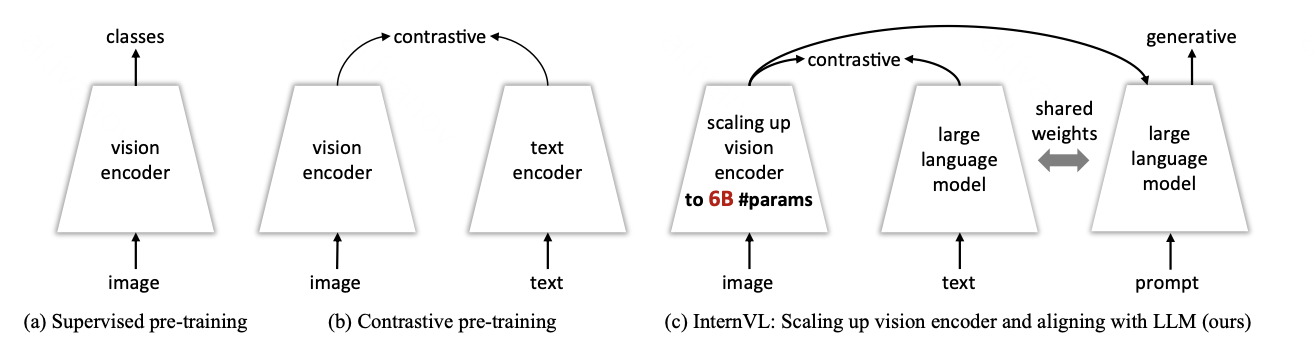
схема трёхстадийного предобучения InternVL 1.0 из статьи — Stage 1: contrastive (InternViT + LLaMA), Stage 2: generative (QLLaMA), Stage 3: SFT

**Стадия 1: Vision-Language Contrastive Training**

InternViT-6B + LLaMA-7B обучаются контрастивно на 5B пар данных. Цель: научить InternViT порождать семантически богатые эмбеддинги, согласованные с текстом.

**Стадия 2: Vision-Language Generative Training с QLLaMA**

Вводится **QLLaMA** — Q-Former-подобный модуль, инициализованный весами LLaMA-7B вместо случайной инициализации, как в BLIP-2. В отличие от Q-Former в BLIP-2 (12-слойный трансформер с нуля), QLLaMA начинает с богатых языковых репрезентаций. QLLaMA обучается с тремя потоками потерь: ITC, ITM, ITG.

**Стадия 3: SFT**

QLLaMA соединяется с более мощным LLM (Vicuna-13B) через MLP. Тренировочные данные — instruction-following датасеты.

### 2. InternVL 1.5: смена архитектуры и dynamic tiling

InternVL 1.5 (апрель 2024) — принципиальная смена дизайна. QLLaMA выброшен. Используется простая **ViT-MLP-LLM** схема, но с мощным InternViT-6B и dynamic tiling.

**Dynamic High-Resolution (Dynamic Tiling):**

Изображение разбивается на тайлы (tiles) 448×448 пикселей. Число тайлов от 1 до 12 подбирается по aspect ratio:

```python
def find_closest_aspect_ratio(image_w, image_h, min_tiles=1, max_tiles=12):
    target_aspect = image_w / image_h
    best_config = None
    min_diff = float('inf')
    for n_rows in range(1, max_tiles + 1):
        for n_cols in range(1, max_tiles + 1):
            if n_rows * n_cols > max_tiles:
                continue
            config_aspect = n_cols / n_rows
            diff = abs(config_aspect - target_aspect)
            if diff < min_diff:
                min_diff = diff
                best_config = (n_rows, n_cols)
    return best_config

# Дополнительно всегда добавляется thumbnail (ресайз до 448×448)
# для глобального понимания — итого N+1 тайл
```

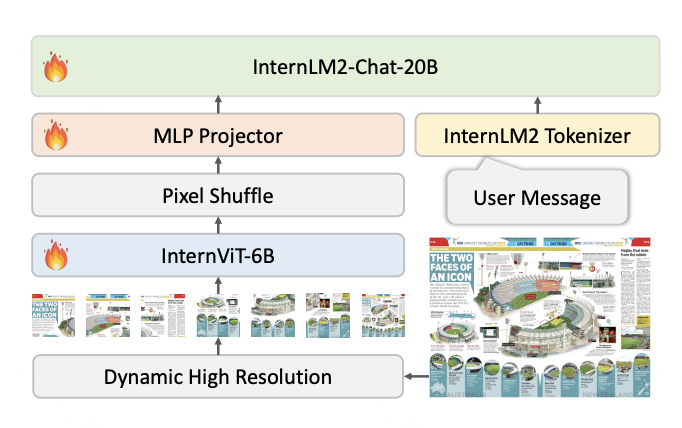

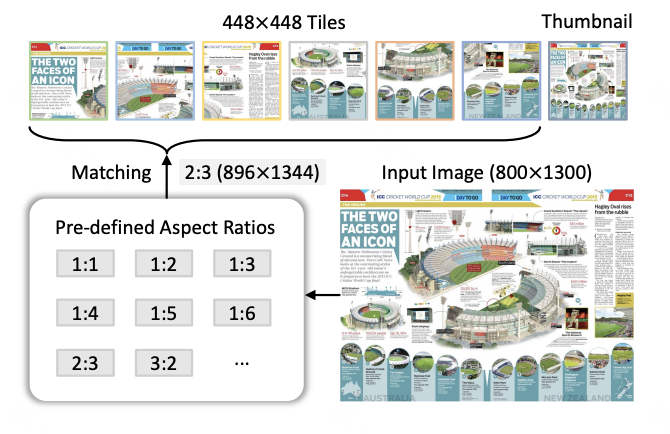

При patch size 14 и input size 448: $(448/14)^2 = 1024$ токена на тайл.

**MLP проектор:** двухслойный MLP с GeLU. Входная размерность 3200 (InternViT), выходная — hidden dim LLM.

### 3. InternVL 2.0: Pixel Unshuffle

InternVL 2.0 (июль 2024) вводит **pixel unshuffle** для снижения числа токенов.

**Pixel Unshuffle:** операция, обратная sub-pixel convolution. Берёт тензор $H \times W \times C$ и формирует $(H/r) \times (W/r) \times (C \cdot r^2)$. При $r = 2$: 1024 токена на тайл → **256 токенов**.

Почему именно пространственное сжатие, а не average pooling? Pixel unshuffle сохраняет **все** пиксели без потери информации — информация из 4 патчей не усредняется, а конкатенируется вдоль канального измерения.

### 4. Позиционные эмбеддинги: V2PE

**InternVL 3.0** вводит **V2PE (Variable Visual Position Encoding)**.

Проблема: при тайлинге 12 тайлов × 256 токенов = 3072 визуальных токена. Если им присваивать позиции последовательно вместе с текстовыми токенами, то текстовые токены начинаются с позиции ~3072, что нарушает распределение позиционных эмбеддингов.

**V2PE:** каждый визуальный токен получает позиционный инкремент $\delta < 1$ вместо стандартного 1. 256 токенов одного тайла занимают «позиции» от 0 до $256\delta$, а не от 0 до 256. Текстовые токены располагаются в «привычной» позиционной области.

### 5. Эволюция LLM-декодера

| Версия | LLM | Параметры |
|--------|-----|-----------|
| InternVL 1.0–1.1 | Vicuna / InternLM | 13B |
| InternVL 1.2 | Yi-34B | 34B |
| InternVL 1.5 | InternLM2-20B | 20B |
| InternVL 2.0 | InternLM2.5 (разные размеры) | 1B–108B |
| InternVL 2.5 | **Qwen2.5** + InternLM2.5 | 0.5B–78B |
| InternVL 3.0/3.5 | Qwen2.5/InternLM3 | 1B–78B |

Переход на Qwen2.5 в InternVL 2.5 демонстрирует модульность подхода: visual encoder (InternViT) и LLM можно «собирать» независимо.

### 6. Стадии обучения InternVL 2.x/3.x

**InternVL 2.0 / 2.5 — двухстадийное обучение:**

1. **MLP Warmup** — обучается только MLP-проектор, ViT и LLM заморожены.
2. **Full Fine-tuning** — все компоненты разморожены. Loss Reweighting в InternVL 2.5: каждой задаче назначается вес, пропорциональный сложности.

**InternVL 3.x — Native Multimodal Pre-Training:**

```
Мультимодальный пре-трейн: чередование (image-text), (video-text), (text-only) батчей
           ↓
   Supervised Fine-Tuning (SFT)
           ↓
  Mixed Preference Optimization (MPO)
```

**MPO:** разновидность DPO/RLHF для мультимодального контекста, использующая смешанный сигнал из нескольких источников предпочтений.

### 7. InternVL Flash и ViCO

> **Статья:** "ViCO: A Training Strategy towards Semantic Aware Dynamic High Resolution for VLM", arXiv 2025.  
> **Ссылка:** https://arxiv.org/abs/2510.12793

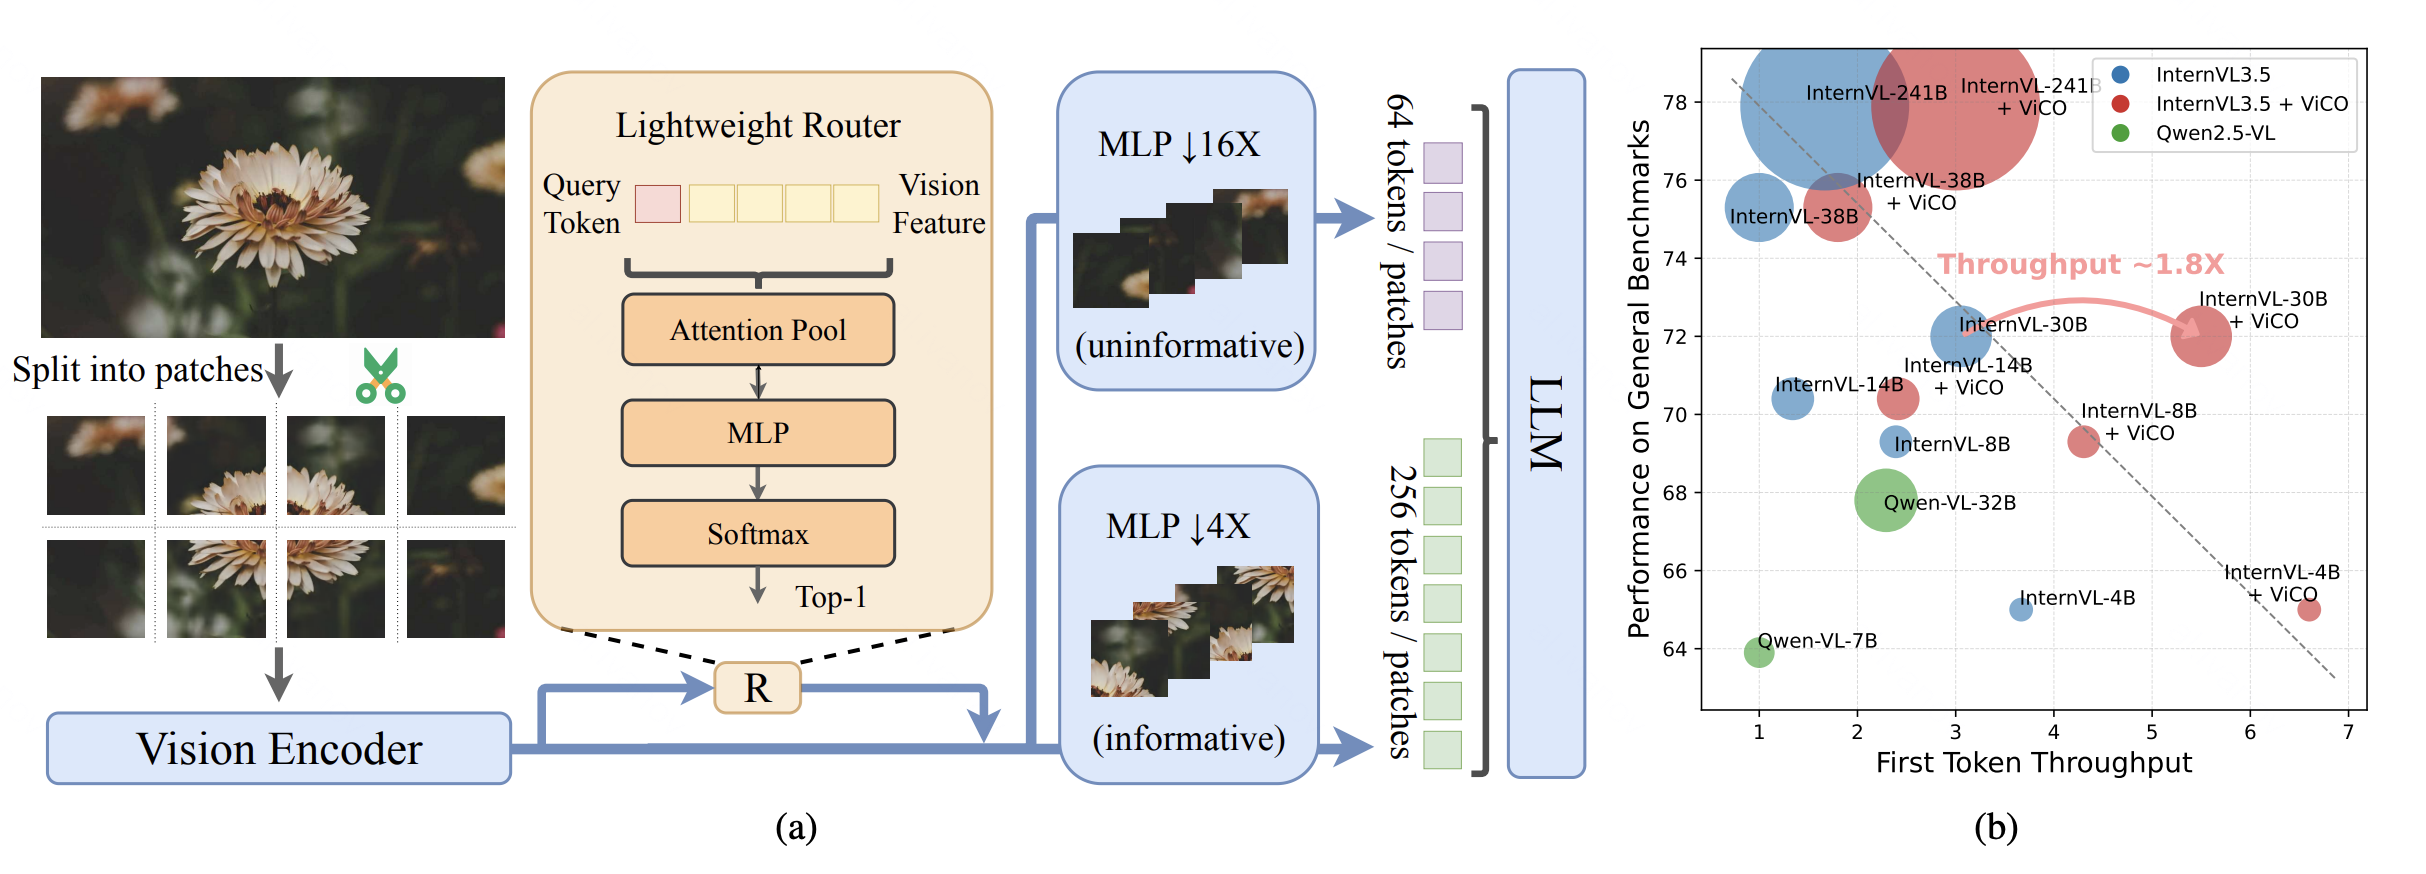

**ViCO (Visual Consistency Learning):**

Используется **несколько MLP-коннекторов** с разными степенями компрессии:
- **MLP-1/4:** компрессия 4x (256 токенов на тайл)
- **MLP-1/16:** компрессия 16x (64 токена на тайл)

Во время обучения коннектор выбирается случайно. Обучение минимизирует KL-дивергенцию между ответами при разных уровнях компрессии:

$$
\mathcal{L}_{\text{ViCO}} = \mathcal{L}_{\text{CE}} + \lambda \cdot D_{\text{KL}}\!\left(p_\theta(y \mid x, \text{high-res}) \;\|\; p_\theta(y \mid x, \text{low-res})\right)
$$

При инференсе **Visual Resolution Router (ViR)** предсказывает оптимальную компрессию. Результат: до 50% сокращение визуальных токенов без заметной потери качества.

***



## Gemma 2/3/4

> **Статьи:**
> - Gemma 2: "Gemma 2: Improving Open Language Models at a Practical Scale", arXiv 2024. https://arxiv.org/abs/2408.00118
> - Gemma 3: "Gemma 3 Technical Report", arXiv 2025. https://arxiv.org/abs/2503.19786
> - Gemma 4: https://deepmind.google/models/gemma/gemma-4/

Gemma — семейство открытых моделей Google DeepMind.

### 1. SigLIP как image encoder

**Gemma 3** (март 2025) стал первой мультимодальной Gemma. Vision encoder — **SigLIP**, 417M параметров, **заморожен** во время обучения VLM.

**Архитектура visual preprocessing:**

Изображение (по умолчанию 896×896, то есть 64×64 = 4096 патчей по 14×14) → SigLIP → **256 soft tokens** через свёрточный pooling (2x2 stride-2) + MLP.

Для несквадратных изображений применяется **Pan and Scan (P&S)**:
1. Изображение нарезается на непересекающиеся кропы 896×896
2. Каждый кроп → SigLIP → 256 токенов
3. Все наборы токенов конкатенируются + «обзорный» токен от всего изображения

Итоговый формат:
```
[Overview tokens (256)] [Crop1 tokens (256)] [Crop2 tokens (256)] ... [Text tokens]
```

**Почему заморожен encoder?** SigLIP уже обучен на огромных данных; разморозка ViT при маленьких learning rate'ах даёт минимальный прирост при большем GPU memory.

### 2. Knowledge Distillation как способ создания семейства

**Gemma 2** ввела knowledge distillation как основной метод получения меньших моделей.

### Что такое Knowledge Distillation

**Knowledge Distillation (KD)** (Hinton et al., 2015) — техника обучения компактной модели (студент) с использованием знаний большой модели (учитель). Мотивация: большие модели параметрически избыточны, но несут богатую неявную информацию в своих выходных распределениях. Студент обучается воспроизводить не только правильные метки, но и **мягкое распределение** вероятностей учителя.

Классификация KD по типу знаний:

| Вид | Что дистиллируется | Пример применения |
|-----|-------------------|-------------------|
| **Response-based (логит-дистилляция)** | Выходные логиты / вероятности учителя | Gemma 2/3, Qwen3 LLM |
| **Feature-based** | Промежуточные активации (hidden states, attention maps) | TinyBERT, PKD |
| **Relation-based** | Структура попарных сходств между примерами | CRD, RKD |

**Self-distillation:** учитель и студент — одна и та же модель (разные слои или итерации). Применяется для сжатия без внешнего учителя.

**Online distillation:** несколько студентов обучают друг друга одновременно, без фиксированного учителя.

**Использование дистилляции в моделях этого доклада:**
- **Gemma 2/3:** логит-дистилляция из 27B → 9B/4B при одновременном NTP-обучении. Учитель заморожен; студент видит только распределения учителя.
- **InternVL 3.x:** MPO содержит элементы дистилляции — предпочтительные ответы могут генерироваться более крупной версией той же модели.
- **Qwen3 (языковая база Qwen3-VL):** при создании малых плотных моделей (2B, 4B) применяется дистилляция из флагманской MoE-модели (235B-A22B).

### Математика дистилляции

**Стандартный NTP (Next Token Prediction):**

$$
\mathcal{L}_{\text{NTP}} = -\log p_\theta(x_t | x_{<t}) = \text{CE}(e_{x_t}, \mathbf{p}_\theta)
$$

где $e_{x_t}$ — one-hot вектор, $\mathbf{p}_\theta$ — предсказание модели.

**Knowledge Distillation:**

$$
\mathcal{L}_{\text{distill}} = (1 - \alpha) \cdot \mathcal{L}_{\text{NTP}} + \alpha \cdot D_{\text{KL}}\!\left(\mathbf{p}_{\text{teacher}} \;\|\; \mathbf{p}_\theta\right)
$$

или в чистом виде:

$$
\mathcal{L}_{\text{distill}} = \sum_v p_{\text{teacher}}(v | x_{<t}) \log \frac{p_{\text{teacher}}(v | x_{<t})}{p_\theta(v | x_{<t})}
$$

**Почему knowledge distillation лучше NTP для маленьких моделей:**
- Teacher-логиты несут **мягкую информацию**: вместо one-hot [0,...,1,...,0] на слове «автомобиль» teacher даёт [0.6 «автомобиль», 0.3 «машина», 0.05 «транспорт», ...]. Это богатый сигнал о семантических сходствах.
- **Результат:** Gemma 2 9B конкурирует с 27B–13B моделями, обученными «с нуля».

### 3. Архитектурные особенности Gemma 2/3

**Formatting**

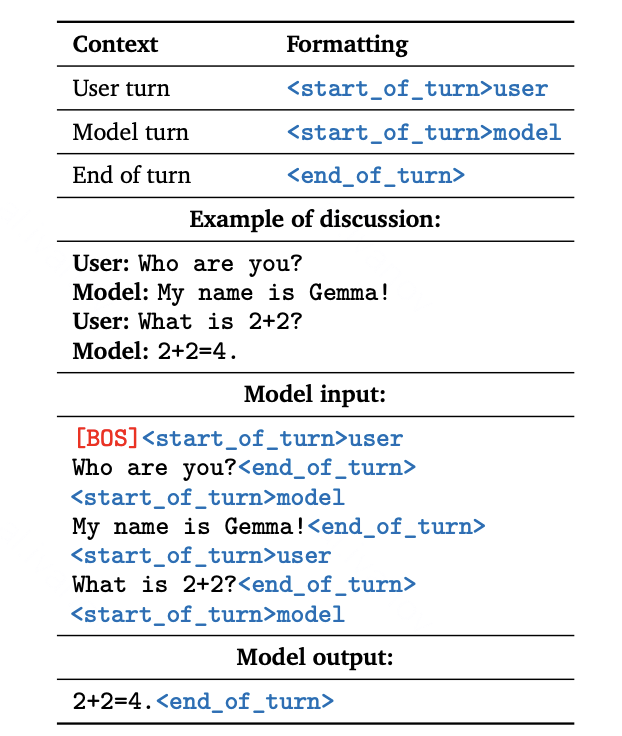

**Interleaved Local/Global Attention:**

Gemma 2/3 чередует:
- **Local (Sliding Window) Attention:** каждый токен видит только окно из $w = 4096$ соседей. Сложность: $O(n \cdot w)$
- **Global Attention:** стандартный полный attention. Сложность: $O(n^2)$

Соотношение: каждые 5–6 локальных слоёв → 1 глобальный слой. Экономия KV-cache на 128K контексте достигает 85%.

Для токена $i$ в слое с local attention:

$$
\text{out}_i = \text{Attention}(q_i, \{k_j, v_j : |i - j| \leq w/2\})
$$

**GQA (Grouped Query Attention):** $H_Q$ query-голов делятся на $G$ групп, каждая группа шарит одну пару $K, V$. KV-cache уменьшается в $H_Q/G$ раз.

**Logit soft-capping:**

$$
\hat{z} = z_{\max} \cdot \tanh(z / z_{\max})
$$

Предотвращает численную нестабильность при обучении на длинных контекстах.

### 4. Обновления в семействе

**Gemma 2 (2024):** text-only, 2B/9B/27B, knowledge distillation, interleaved attention, logit soft-capping.

**Gemma 3 (март 2025):** мультимодальность (SigLIP, frozen), 1B/4B/12B/27B, 128K контекст для 4B+, поддержка 140+ языков.

Технические изменения в Gemma 3 vs 2:
- Увеличено соотношение local/global attention с 5:1 → 6:1
- Tokenizer обновлён до Gemini 2.0 tokenizer (**262K vocab** — SentencePiece с byte-level encodings, улучшены не-латинские языки; Gemma 2 имела 256K vocab)
- RoPE base = 1 000 000 для длинного контекста

**Gemma 4 (апрель 2025):** MoE-архитектура на основе Gemma 3 27B, улучшенные multimodal capabilities, более длинный контекст.

***


## Qwen-VL

> **Статьи:**
> - Qwen-VL: Bai et al., "Qwen-VL: A Versatile Vision-Language Model", arXiv 2023. https://arxiv.org/abs/2308.12966
> - Qwen2-VL: Wang et al., "Qwen2-VL: Enhancing Vision-Language Model's Perception of the World at Any Resolution", arXiv 2024. https://arxiv.org/abs/2409.12191
> - Qwen2.5-VL: Qwen Team, "Qwen2.5-VL Technical Report", arXiv 2025. https://arxiv.org/abs/2502.13923
> - Qwen3-VL: Bai et al., "Qwen3-VL Technical Report", arXiv 2025. https://arxiv.org/abs/2511.21631
> - Qwen3.5: "Qwen3.5-Omni Technical Report" https://arxiv.org/abs/2604.15804

Семейство мультимодальных моделей от Alibaba DAMO Academy / Qwen Team.

### 1. Qwen-VL: архитектура image encoder и Q-Former компрессор

**Qwen-VL (2023):** ViT (инициализованный из OpenCLIP ViT-bigG, ~1.9B параметров) + **cross-attention компрессор**.

```
Image → ViT-bigG (patch size 14, stride 14) → N патч-токенов
                    ↓
         Cross-attention компрессор (один трансформерный слой)
         256 learnable query-векторов
         Q_i attend по K,V из ViT-вывода
                    ↓
            256 visual tokens → LLM (Qwen-7B)
```

**Специальные токены:** `<img>`, `</img>` — разделители. `<ref>text</ref>` и `<box>x1,y1,x2,y2</box>` — для grounding. Это позволяет Qwen-VL поддерживать задачи visual grounding «из коробки».

### 2. Qwen2-VL: Naive Dynamic Resolution и M-RoPE

**Qwen2-VL (сентябрь 2024)** — принципиальная смена архитектуры. Убирается Q-Former компрессор. Вводится **Naive Dynamic Resolution**.

ViT инициализован из DFN (~675M параметров). Ключевые отличия:
- **Window attention** с размером окна 8×8 патчей + редкие глобальные слои
- **2D RoPE внутри ViT** вместо learnable positional embeddings
- **SwiGLU** вместо MLP: $\text{SwiGLU}(x) = \text{Swish}(xW_1) \odot (xW_2)$
- **RMSNorm** вместо LayerNorm

Изображение обрабатывается в **нативном разрешении**:

```python
def smart_resize(image_w, image_h, factor=28,
                 min_pixels=256*28*28, max_pixels=1280*28*28):
    pixels = image_w * image_h
    if pixels < min_pixels:
        scale = (min_pixels / pixels) ** 0.5
    elif pixels > max_pixels:
        scale = (max_pixels / pixels) ** 0.5
    else:
        scale = 1.0
    new_w = round(image_w * scale / factor) * factor
    new_h = round(image_h * scale / factor) * factor
    return new_w, new_h
```

Число токенов: $(H \times W) / (14^2 \times 4)$ после pixel unshuffle (factor 2).

**M-RoPE:** разбиение head dimension на три части (temporal/height/width). Для Qwen2-VL при $d_h = 128$: temporal 40 dim, height 44 dim, width 44 dim.

### 3. Процесс обучения

**Qwen2-VL — обновлённый пайплайн:**

1. Предобучение visual encoder (CLIP-style с нативным разрешением)
2. VLM alignment: замороженный LLM, обучается только MLP-проектор
3. End-to-end pre-training: всё размораживается, ~1T мультимодальных токенов
4. Post-training (SFT + RL): instruction fine-tuning, затем GRPO/RLVR для reasoning

### 4. Работа с видео

Видеокадры сэмплируются с **динамическим FPS**. M-RoPE temporal dimension кодирует порядок кадров.

**Qwen2.5-VL: Absolute Time Encoding**

Temporal IDs выровнены с **абсолютным временем**: для кадра на секунде $t$:

$$
\text{temporal\_id}[\text{frame at time } t] = \lfloor t \cdot \text{scale\_factor} \rfloor
$$

Это позволяет модели «знать» скорость события — в Qwen2-VL temporal IDs просто инкрементально нумеровали кадры.

**3D свёрточный patch merger:** для видео патчи объединяются пространственно (2×2) и временно (2 соседних кадра). Снижение токенов ~в 8 раз.

### 5. Эволюция семейства

**Qwen-VL (2023):** ViT-bigG + Q-Former компрессор + Qwen-7B. Фиксированное разрешение 448×448. Первая модель с grounding.

**Qwen2-VL (сентябрь 2024):** убран Q-Former. Нативное разрешение + M-RoPE. Unified image/video processing. 2B, 7B, 72B.

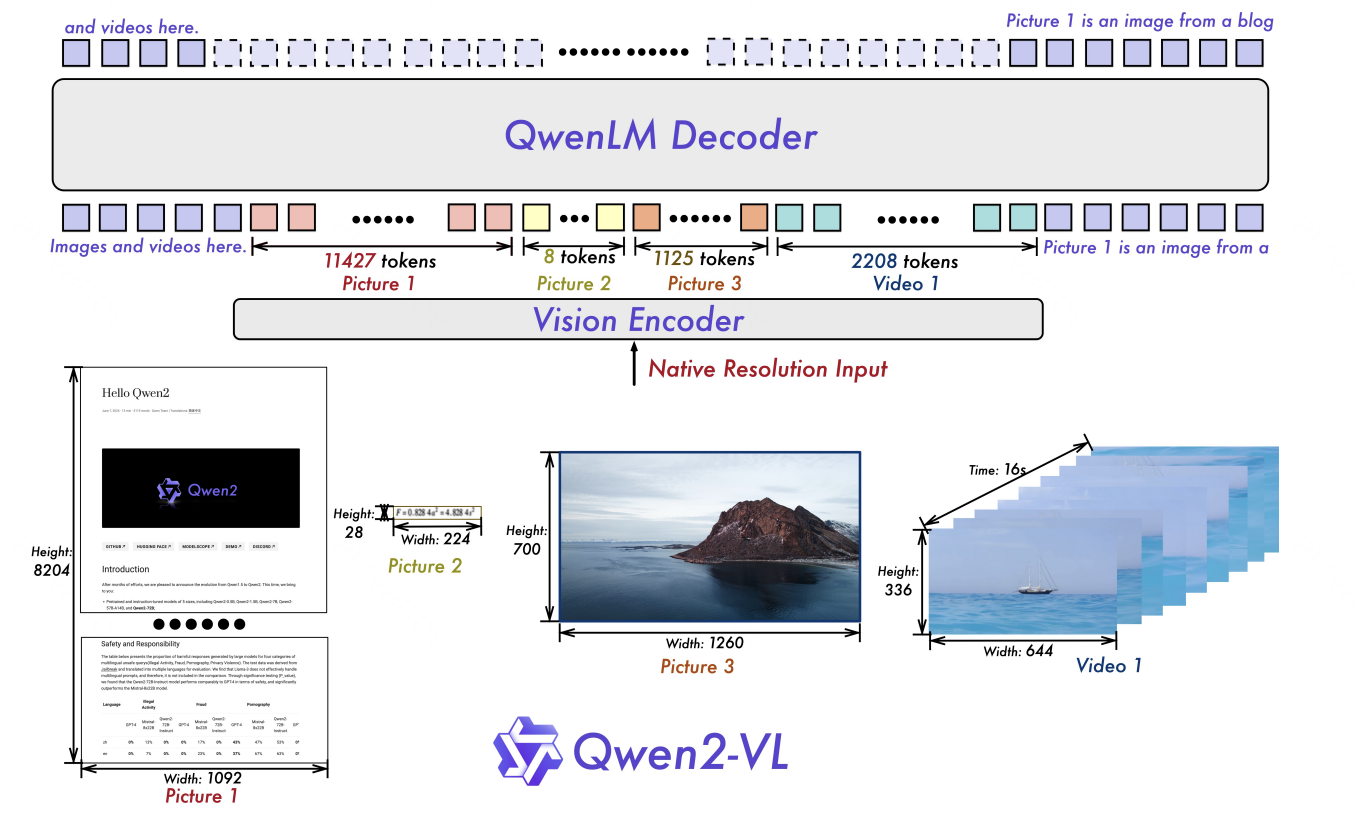

**Qwen2.5-VL (январь 2025):** улучшен temporal understanding (absolute time). Оптимизирован ViT (SwiGLU, RMSNorm). Длинные видео (1+ час). RL-этап. 3B, 7B, 72B.

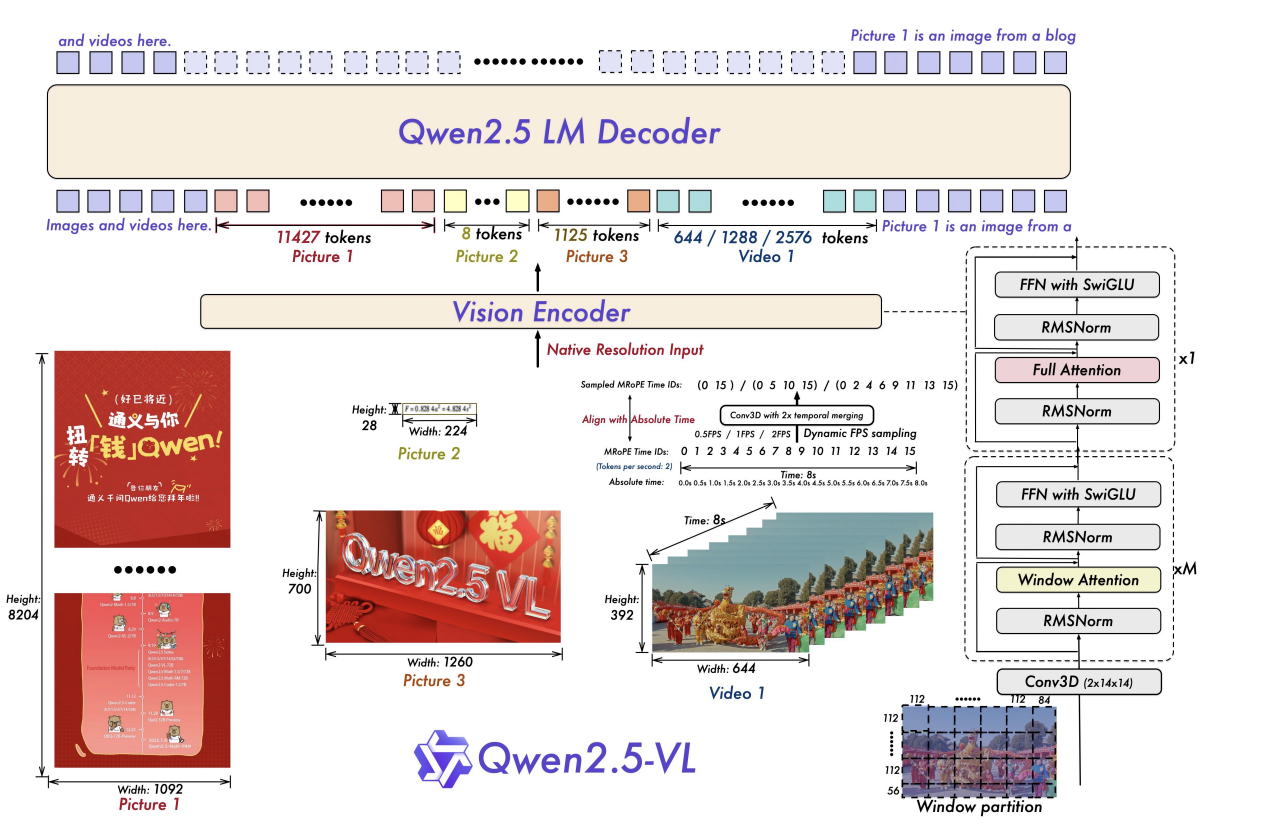

**Qwen3-VL (ноябрь 2025):** до 256K токенов. **DeepStack** — многоуровневые ViT-признаки инжектируются в LLM. 2B, 4B, 8B, 32B (dense) + 30B-A3B, 235B-A22B (MoE).

**DeepStack:** вместо только финального ViT-выхода берутся выходы промежуточных слоёв и инжектируются в соответствующие слои LLM. LLM получает доступ как к низкоуровневым деталям (ранние ViT-слои), так и к семантике (поздние).

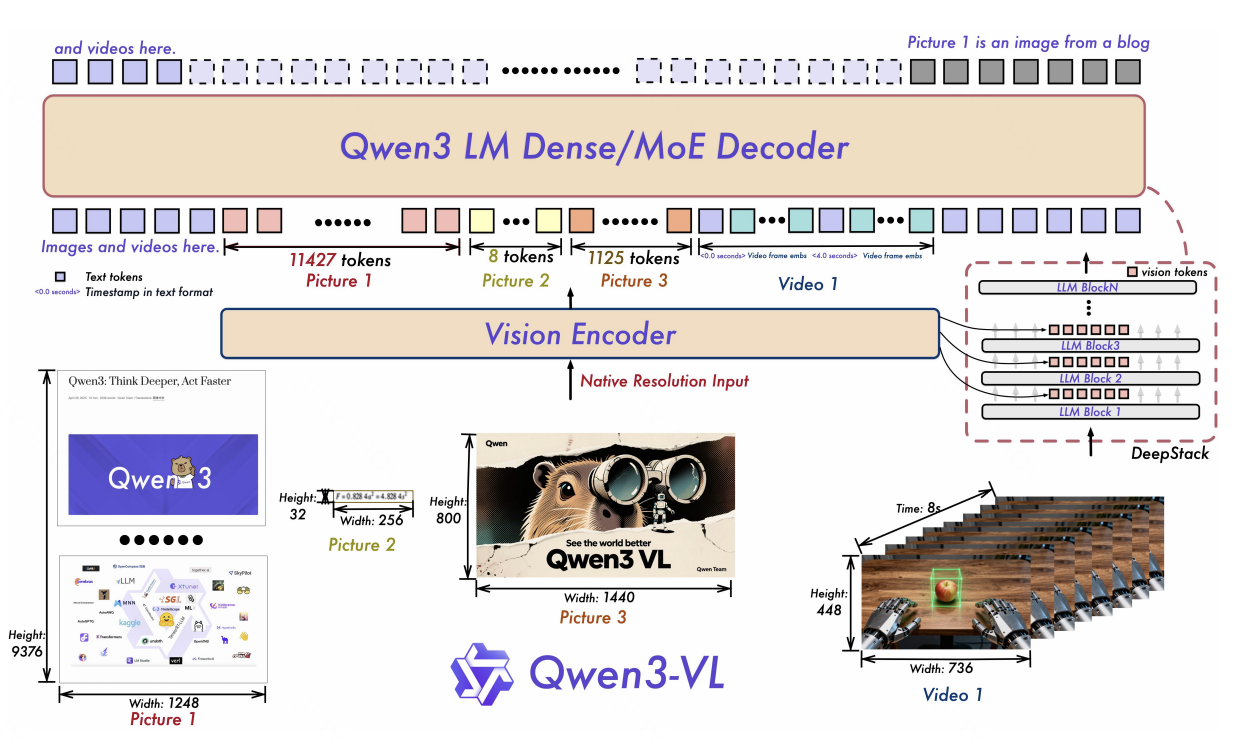

**Qwen3.5 / Qwen3.5-VL (февраль 2026):** Alibaba анонсировала серию Qwen3.5 16 февраля 2026 года. Флагман — **Qwen3.5-397B-A17B**: MoE с 397B общими / 17B активными параметрами. Qwen3.5 — **унифицированная** мультимодальная серия: VLM и LLM объединены в единую точку входа (в отличие от раздельных Qwen-VL и Qwen-LLM прежде).

Ключевые улучшения Qwen3.5:
- **Unified Vision-Language Foundation:** единое совместное предобучение на мультимодальных токенах (text + image + video)
- **Гибридная архитектура GDN (Gated Delta Networks)** — слои чередуются с Gated Attention в соотношении 3:1 (см. раздел Qwen3-Next ниже)
- **Контекст 2M токенов** через YaRN + O(1) inference в GDN-слоях
- **8.6× быстрее** Qwen3-Max на 32K контексте, **19×** на 256K
- **201 язык и диалект**
- Размерный ряд открытых моделей: 0.8B, 2B, 4B, 9B, 27B, 35B-A3B, 122B-A10B, 397B-A17B (все Apache 2.0)

### 6. Qwen3-Next: гибридная архитектура

> **Статья:** Yang et al., "Gated Delta Networks: Improving Mamba2 with Delta Rule", ICLR 2025. https://arxiv.org/abs/2412.06464

**Qwen3-Next (сентябрь 2025)** — гибридная архитектура для сверхдлинных контекстов с ultra-sparse MoE.

#### 6.1 Мотивация: проблема O(n²) в трансформере

При длинных контекстах (32K+) классический трансформер становится дорогим: attention — O(n²). Линейные модели дают O(n), но хуже «помнят» точные детали.

#### 6.2 DeltaNet: линейный attention с delta rule

**Линейный attention** — убирается softmax:

$$
S_t = S_{t-1} + \phi(k_t)^\top v_t \in \mathbb{R}^{d_k \times d_v}, \quad \text{out}_t = \phi(q_t) \cdot S_t
$$

Inference — O(1) per step. Проблема: **слабый recall** — матрица $S_t$ аккумулирует все прошлые пары без разбора.

**Delta rule** решает retrieval. «Ошибочно-корректирующее» обновление:

$$
S_t = S_{t-1} + k_t^\top (v_t - k_t S_{t-1}) = (I - k_t^\top k_t) S_{t-1} + k_t^\top v_t
$$

Если ключ уже «запомнен», обновление минимально. Если запись противоречит предыдущей — **перезаписывается**.

#### 6.3 Gated DeltaNet

**Gated DeltaNet** объединяет delta rule с гейтовым механизмом:

$$
S_t = \alpha_t \odot S_{t-1} + \beta_t \odot \bigl[k_t^\top (v_t - k_t S_{t-1})\bigr]
$$

где $\alpha_t$ — forget gate (content-dependent), $\beta_t$ — input gate. Выход: $\text{out}_t = q_t \cdot S_t \cdot o_t$ с output gate $o_t$.

Сочетает: O(1) inference + precision recall (delta rule) + adaptive forgetting (gating).

#### 6.4 Архитектура Qwen3-Next

Гибридная схема **3:1** — три слоя GDN на один слой стандартного Gated Attention.

**Ultra-sparse MoE:** 512 экспертов, 10+1 активных. Активация ~3.7% параметров (vs Mixtral: 25%).

**Multi-Token Prediction (MTP):** модель обучается предсказывать несколько следующих токенов одновременно — аналог speculative decoding на уровне архитектуры.

***

## Семейство GLM

> **Статьи:**
> - CogVLM: Wang et al., "CogVLM: Visual Expert for Pretrained Language Models", NeurIPS 2024. https://arxiv.org/abs/2311.03079
> - CogVLM2 / GLM-4V: Hong et al., "CogVLM2: Visual Language Models for Image and Video Understanding", arXiv 2024. https://arxiv.org/abs/2408.16500
> - GLM-4.5V / GLM-4.1V-Thinking: https://arxiv.org/abs/2507.01006

Семейство GLM разрабатывается Zhipu AI (Z.ai) совместно с Tsinghua University.

### История семейства

**VisualGLM (2023):** BLIP-2-style Q-Former + GLM-6B. Базовая функциональность.

**CogVLM (2023):** принципиально новый подход — **Visual Expert Architecture**.

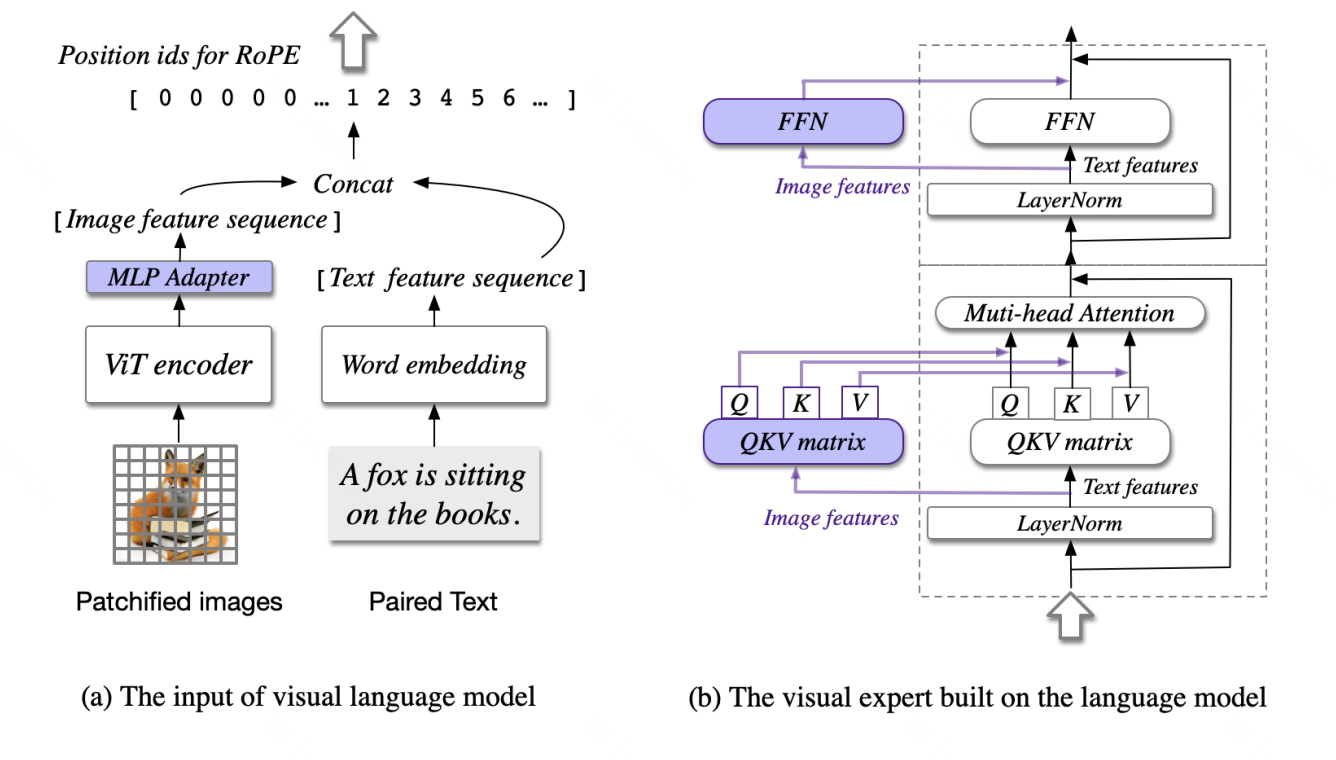

схема Visual Expert из CogVLM paper (Wang et al., 2023) — каждый трансформерный слой LLM содержит дополнительные QKV-матрицы и FFN для визуальных токенов

**Visual Expert: детальный разбор**

В каждом слое LLM добавляются **отдельные** матрицы $W_Q^V, W_K^V, W_V^V$ и FFN для визуальных токенов. Текстовые используют оригинальные веса $W_Q^T, W_K^T, W_V^T$. Обе группы токенов видят друг друга в attention.

Формально для визуального токена $v_i$:

$$
Q_i^V = W_Q^V v_i, \quad K_j = \begin{cases} W_K^V v_j & j \leq N \\ W_K^T t_j & j > N \end{cases}, \quad V_j = \begin{cases} W_V^V v_j & j \leq N \\ W_V^T t_j & j > N \end{cases}
$$

**Почему лучше shallow alignment (LLaVA-style)?** В LLaVA линейная проекция переводит визуальные эмбеддинги в embedding space **один раз**. В CogVLM каждый слой применяет **разные преобразования** к визуальным токенам — адаптивная обработка каждой модальности.

Цена: CogVLM-17B ~= 7B LLM + 10B visual expert.

### CogVLM2 (2024)

Наследует visual expert. **Разрешение до 1344×1344** через тайлинг с кропами 672×672. Число токенов сжимается через 2×2 pooling. **CogVLM2-Video:** multi-frame input с временными метками.

### GLM-4.1V-Thinking и GLM-4.5V (2025)

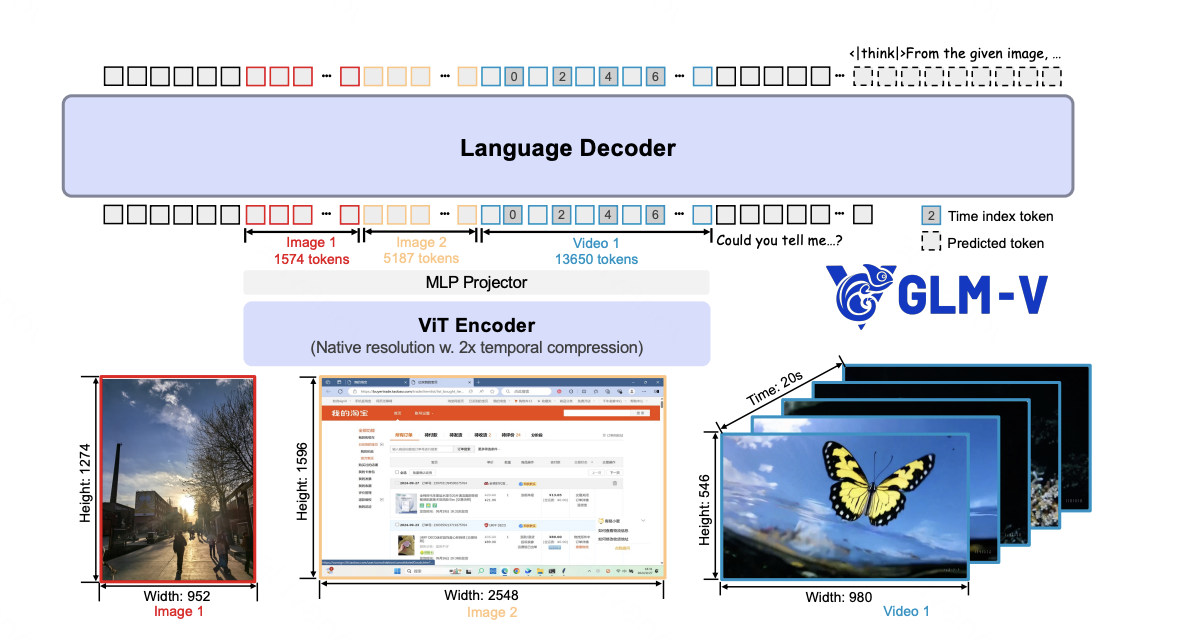

**AIMv2-Huge как visual encoder:** autoregressive image modeling вместо contrastive learning — предсказывает следующий патч изображения авторегрессионно.

**RLCS (Reinforcement Learning with Curriculum Sampling):**

1. Задачи ранжируются по «pass rate» базовой модели
2. Обучение начинается с простых, переходит к сложным
3. Multi-modal reward: format reward + accuracy reward + visual faithfulness reward

**GLM-4.5V (2025):** MoE, 106B total / 12B active. Thinking Mode switch.

### GLM-4.6V (декабрь 2025)

**Native Function Calling:** нативные вызовы инструментов из мультимодального контекста.

**Visual Feedback Loop:** генерирует код/HTML, рендерит результат как изображение, использует его для самокоррекции.

### Общий паттерн обучения GLM

1. Large-scale pre-training (мультимодальные данные)
2. SFT (instruction-following формат)
3. RL stage (RLHF/RLCS)

***


# Open-source vs Closed-source

Несмотря на значительный прогресс open-source VLM, между открытыми и закрытыми моделями существуют существенные различия.

## Что задекларировано, но не открыто

### Данные обучения

Все перечисленные open-source модели **не публикуют** полный состав данных: InternVL, Qwen-VL, GLM упоминают датасеты в общих чертах, конкретные соотношения закрыты. **Gemini, GPT-4V, Claude** не раскрывают ни архитектуру, ни данные.

### Полные pipeline дообучения

RLHF/RLAIF данные, reward model — закрыты у всех. У Qwen3-VL декларируется RL с верифицированными ответами, но конкретика не раскрыта.

### Специфика закрытых моделей

**Gemini 1.5 / 2.x:**
- Нативная мультимодальность (audio + video + image + text) единым трансформером — архитектура не раскрыта
- Контекст до 2M токенов — детали реализации закрыты
- «Mixture of Experts» декларируется, конфигурация закрыта
- Есть инсайты для лекции :-)

**GPT-4V / GPT-4o:**
- Архитектура полностью закрыта
- «Omni» — нативная обработка аудио, точная архитектура неизвестна

**Claude 3.x:**
- Архитектурных деталей не публикуется
- Constitutional AI + RLHF описаны в общих чертах

## Что открыто у open-source моделей

| Компонент | InternVL | Qwen-VL | GLM-4.1V | MiniCPM-V |
|-----------|----------|---------|----------|-----------|
| Веса модели | Да | Да | Да | Да |
| Архитектурные детали | Да | Да | Да | Да |
| Код обучения | Частично | Частично | Частично | Да |
| Полные данные | Нет | Нет | Нет | Нет |
| Reward model | Нет | Нет | Нет | Нет |
| Полный eval pipeline | Частично | Частично | Частично | Нет |

## Практический разрыв

Quantitatively, gap между open-source и closed-source на сложных задачах (MMMU Pro, MathVista hard, Document Understanding) составляет 5–15% в пользу закрытых моделей. На стандартных задачах (VQA, OCR, simple reasoning) Qwen3-VL-235B или GLM-4.5V вплотную приближаются к Gemini 2.5 Flash.

**Тренд:** разрыв сокращается. Основное преимущество закрытых моделей сегодня — более качественные данные и тщательный alignment, а не архитектурные инновации.

***


# Как обучаются современные VLM: итоговое саммари

Пройдя по всем рассмотренным архитектурам, можно выделить общий паттерн обучения, который с теми или иными вариациями воспроизводится во всех современных VLM.

## Pretrain (предобучение)

Предобучение VLM обычно состоит из нескольких подэтапов, образующих «лестницу» от отдельных компонентов к единой системе.

**Шаг 1 — Инициализация компонентов:** visual encoder (ViT) инициализуется из уже обученной модели — CLIP, SigLIP, DFN или их вариаций. LLM инициализуется из открытого языкового чекпоинта (Qwen2.5, InternLM, Vicuna). Оба компонента уже обладают богатыми представлениями в своих модальностях.

**Шаг 2 — Alignment (connector warmup):** на крупных коллекциях image-caption пар (~100M–1B пар) обучается только проектор (MLP или Q-Former). Оба компонента заморожены. Задача — «синхронизировать» пространства признаков ViT и LLM: научить проектор переводить визуальные эмбеддинги в embedding space, понятный LLM.

**Шаг 3 — End-to-end VLM pretraining:** все компоненты размораживаются. На смешанных мультимодальных данных (image-text, video-text, text-only, OCR, grounding) обучается вся система совместно. Обычно 100B–1T мультимодальных токенов. Потери — стандартный NTP по текстовым токенам; визуальные токены выступают «условием», но не таргетом.

На этом этапе модель усваивает общие мультимодальные паттерны: что изображения содержат объекты, как описывать сцены, как читать документы.

## SFT (Supervised Fine-Tuning)

После pretrain модель «знает» многое, но плохо следует инструкциям — она скорее завершает тексты, чем отвечает на вопросы. SFT исправляет это.

**Формат данных:** instruction-following датасеты — пары (вопрос/инструкция + изображение → ответ). Данные охватывают широкий спектр задач: VQA, OCR, document understanding, grounding, captioning, multi-image диалоги, math/code с изображениями.

**Что обучается:** как правило, весь LLM (или LLM + проектор). ViT часто замораживают или обучают с очень маленьким lr — он уже хорошо кодирует изображения.

**Ключевой вызов SFT:** качество данных важнее количества. 100K высококачественных instruction примеров превосходят 1M слабоаннотированных. Именно поэтому команды закрывают данные — это часто важнее архитектуры.

После SFT модель становится полезным ассистентом, способным работать с изображениями в диалоге.

## RL (Reinforcement Learning) — кратко

После SFT ряд современных моделей (Qwen3-VL, GLM-4.1V-Thinking, InternVL 3.x с MPO) добавляет стадию RL. Цель — дальнейшее улучшение качества reasoning, alignment с предпочтениями людей и поведение на трудноформализуемых задачах.

Как правило, используется GRPO, DPO или их вариации с верифицированными ответами. На математических и кодовых задачах reward — программная верификация; на общих задачах — reward model или LLM-as-judge.

Детальный разбор RL-методов для VLM — возможно, поговорим об этом во второй части.

***
